In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Supaya grafik tampil rapi
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [ ]:
from google.colab import files
files.upload()

Saving cropdata_updated.csv to cropdata_updated.csv


{'cropdata_updated.csv': b'crop ID,soil_type,Seedling Stage,MOI,temp,humidity,result\r\nWheat,Black Soil,Germination,1,25,80,1\r\nWheat,Black Soil,Germination,2,26,77,1\r\nWheat,Black Soil,Germination,3,27,74,1\r\nWheat,Black Soil,Germination,4,28,71,1\r\nWheat,Black Soil,Germination,5,29,68,1\r\nWheat,Black Soil,Germination,6,30,65,1\r\nWheat,Black Soil,Germination,7,31,62,1\r\nWheat,Black Soil,Germination,8,32,59,1\r\nWheat,Black Soil,Germination,9,33,56,1\r\nWheat,Black Soil,Germination,10,34,53,1\r\nWheat,Black Soil,Germination,11,35,50,1\r\nWheat,Black Soil,Germination,12,36,47,1\r\nWheat,Black Soil,Germination,13,37,44,1\r\nWheat,Black Soil,Germination,14,38,41,1\r\nWheat,Black Soil,Germination,15,39,38,1\r\nWheat,Black Soil,Germination,16,40,35,1\r\nWheat,Black Soil,Germination,17,41,32,1\r\nWheat,Black Soil,Germination,18,42,29,1\r\nWheat,Black Soil,Germination,19,43,26,1\r\nWheat,Black Soil,Germination,20,44,23,1\r\nWheat,Black Soil,Germination,21,45,20,1\r\nWheat,Black Soil,G

In [ ]:
import os
print(os.listdir())

['.config', 'cropdata_updated.csv', 'sample_data']


In [ ]:
df = pd.read_csv("cropdata_updated.csv")
df.head()

,crop ID,soil_type,Seedling Stage,MOI,temp,humidity,result
0,Wheat,Black Soil,Germination,1,25,80.0,1
1,Wheat,Black Soil,Germination,2,26,77.0,1
2,Wheat,Black Soil,Germination,3,27,74.0,1
3,Wheat,Black Soil,Germination,4,28,71.0,1
4,Wheat,Black Soil,Germination,5,29,68.0,1


In [ ]:
df.describe()

,MOI,temp,humidity,result
count,16411.000000,16411.000000,16411.000000,16411.000000
mean,43.695387,28.832612,63.487752,0.516178
std,27.160264,9.701465,22.630965,0.621691
min,1.000000,13.000000,15.000000,0.000000
25%,21.000000,20.000000,44.000000,0.000000
50%,41.000000,28.000000,69.200000,0.000000
75%,64.000000,37.000000,84.000000,1.000000
max,100.000000,46.000000,91.000000,2.000000


In [ ]:
df.isnull().sum()

,0
crop ID,0
soil_type,0
Seedling Stage,0
MOI,0
temp,0
humidity,0
result,0


In [ ]:
df = df.dropna()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16411 entries, 0 to 16410
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   crop ID         16411 non-null  object 
 1   soil_type       16411 non-null  object 
 2   Seedling Stage  16411 non-null  object 
 3   MOI             16411 non-null  int64  
 4   temp            16411 non-null  int64  
 5   humidity        16411 non-null  float64
 6   result          16411 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 897.6+ KB


In [ ]:
df.columns

Index(['crop ID', 'soil_type', 'Seedling Stage', 'MOI', 'temp', 'humidity',
       'result'],
      dtype='object')

In [ ]:
df = df[(df["temp"] >= 0) & (df["temp"] <= 60)]
df = df[(df["humidity"] >= 0) & (df["humidity"] <= 100)]

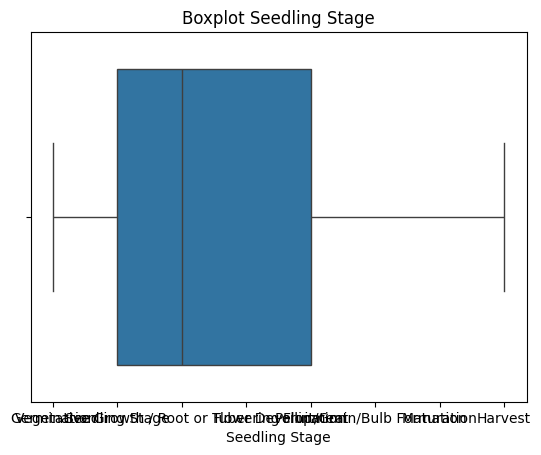

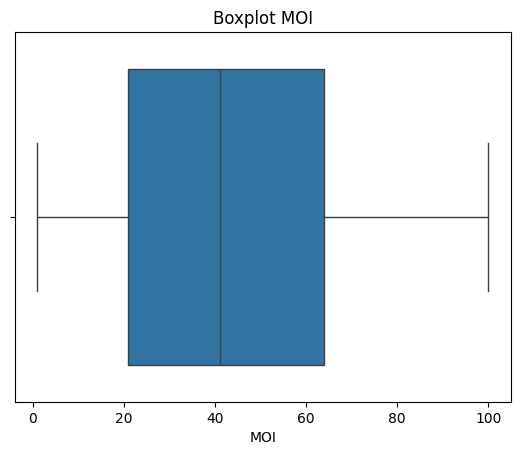

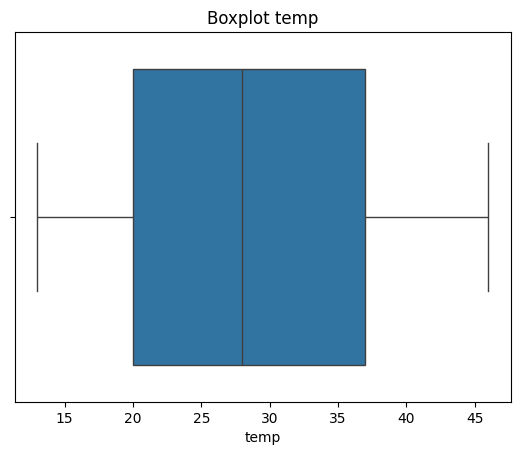

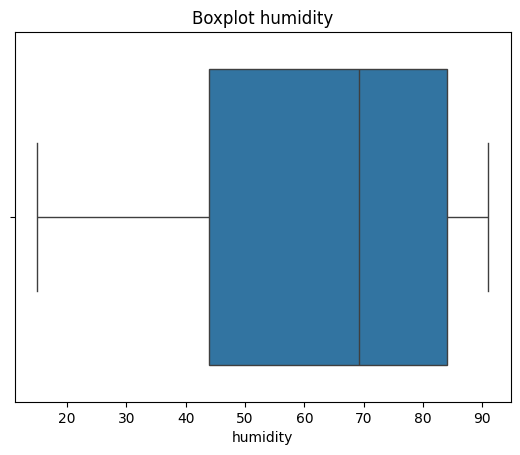

In [ ]:
numeric_cols = ['Seedling Stage', 'MOI', 'temp', 'humidity']

for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot {col}')
    plt.show()

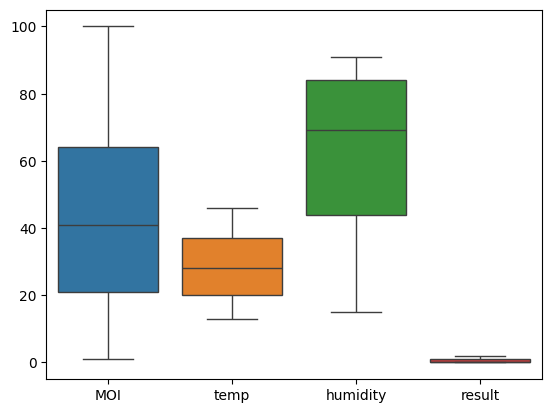

In [ ]:
sns.boxplot(data=df)
plt.show()

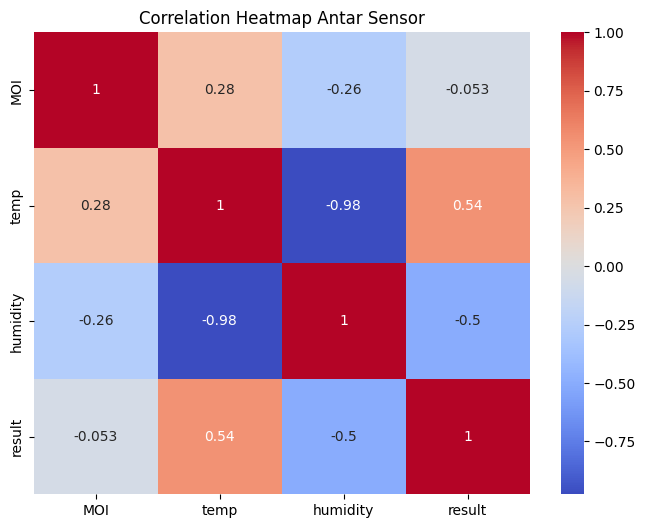

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap Antar Sensor")
plt.show()

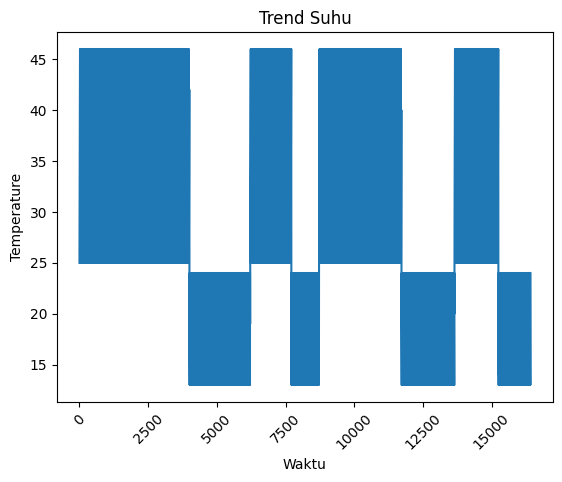

In [ ]:
plt.plot(df["temp"])
plt.title("Trend Suhu")
plt.xlabel("Waktu")
plt.ylabel("Temperature")
plt.xticks(rotation=45)
plt.show()

In [ ]:
df.to_csv("cleaned_data.csv", index=False)

In [ ]:
from google.colab import files
files.download("cleaned_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
missing = df.isnull().sum().sum()
total = df.size

print("Total Missing:", missing)
print("Total Data:", total)

Total Missing: 0
Total Data: 114877


In [ ]:
accuracy = 1 - (missing / total)

print("Accuracy Score:", accuracy)

Accuracy Score: 1.0


In [ ]:
non_null = df.notnull().sum().sum()

completeness = non_null / total

print("Completeness Score:", completeness)

Completeness Score: 1.0


In [ ]:
import pandas as pd

quality_scores = pd.DataFrame({
    "Metric": ["Accuracy", "Completeness"],
    "Score": [accuracy, completeness]
})

quality_scores

,Metric,Score
0,Accuracy,1.0
1,Completeness,1.0
